<a href="https://colab.research.google.com/github/meceugenia/datasets-/blob/main/Proyecto_final_Cejas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final : Clasificación de ansiedad en usuarios de Redes Sociales

## Objetivo

El objetivo de este proyecto es construir un modelo de clasificación que permita predecir si una persona presenta un nivel alto de ansiedad a partir de variables relacionadas con el uso de redes sociales, hábitos de sueño y bienestar emocional.

Para ello, se utilizará el dataset `social_media_mental_health.csv`, se aplicará un método de selección de variables (feature selection), se entrenará un modelo de clasificación y se evaluará su desempeño mediante métricas básicas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [2]:
url_mentalhealth= "https://raw.githubusercontent.com/meceugenia/datasets-/refs/heads/main/social_media_mental_health.csv"
mentalhealth=pd.read_csv(url_mentalhealth)

mentalhealth.head()

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [3]:
mentalhealth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int64  
 9   Social_Comparison_Trigger  8000 non-null   int64  
 10  Sleep_Duration_Hours       8000 non-null   float64
 11  GAD_7_Score                8000 non-null   int64  
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 non-null   int64

In [4]:
mentalhealth.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
User_Archetype,0
Primary_Platform,0
Daily_Screen_Time_Hours,0
Dominant_Content_Type,0
Activity_Type,0
Late_Night_Usage,0
Social_Comparison_Trigger,0


## Identificación de valores perdidos

En esta etapa se revisan los valores faltantes del dataset, ya que pueden afectar el entrenamiento del modelo. La detección de datos nulos es importante para decidir si deben eliminarse registros o imputarse valores antes de continuar con el análisis.

In [8]:
mentalhealth["High_Anxiety"] = (mentalhealth["GAD_7_Score"] >= 10).astype(int)

mentalhealth["High_Anxiety"].value_counts()

,count
High_Anxiety,
0,5310
1,2690


## Definición de la variable objetivo

Para este proyecto se definió una variable objetivo binaria denominada `High_Anxiety`, construida a partir del puntaje `GAD_7_Score`.

- Valor 1: personas con ansiedad alta (`GAD_7_Score >= 10`)
- Valor 0: personas con ansiedad baja o moderada (`GAD_7_Score < 10`)

Esta transformación permite abordar el problema como una tarea de clasificación binaria, facilitando la aplicación de algoritmos supervisados.

In [17]:
features = [
    "Age",
    "Gender",
    "Daily_Screen_Time_Hours",
    "Late_Night_Usage",
    "Sleep_Duration_Hours",
    "PHQ_9_Score"
]

df_model = mentalhealth[features + ["High_Anxiety"]].copy()
df_model.head()

,Age,Gender,Daily_Screen_Time_Hours,Late_Night_Usage,Sleep_Duration_Hours,PHQ_9_Score,High_Anxiety
0,18,Male,8.50,0,3.9,5,0
1,20,Male,0.50,0,5.5,8,0
2,18,Female,0.91,0,8.9,3,0
3,18,Female,7.43,1,6.2,0,1
4,18,Male,4.94,1,5.3,10,1


In [18]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_night = LabelEncoder()

df_model["Gender"] = le_gender.fit_transform(df_model["Gender"].astype(str))
df_model["Late_Night_Usage"] = le_night.fit_transform(df_model["Late_Night_Usage"].astype(str))

df_model.head()

,Age,Gender,Daily_Screen_Time_Hours,Late_Night_Usage,Sleep_Duration_Hours,PHQ_9_Score,High_Anxiety
0,18,1,8.50,0,3.9,5,0
1,20,1,0.50,0,5.5,8,0
2,18,0,0.91,0,8.9,3,0
3,18,0,7.43,1,6.2,0,1
4,18,1,4.94,1,5.3,10,1


In [19]:
X = df_model.drop("High_Anxiety", axis=1)
y = df_model["High_Anxiety"]

In [20]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=4)
X_selected = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]
print("Variables seleccionadas:", list(selected_columns))

Variables seleccionadas: ['Daily_Screen_Time_Hours', 'Late_Night_Usage', 'Sleep_Duration_Hours', 'PHQ_9_Score']


In [21]:
feature_scores = pd.DataFrame({
    "Variable": X.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

feature_scores

,Variable,Score
3,Late_Night_Usage,5116.692279
2,Daily_Screen_Time_Hours,2792.106098
5,PHQ_9_Score,1995.132020
4,Sleep_Duration_Hours,1112.835811
0,Age,2.344167
1,Gender,0.069866


## Selección de variables

Para reducir la dimensionalidad del dataset y conservar únicamente las variables más relevantes para la predicción, se aplicó un método de selección de variables denominado `SelectKBest`.

Este procedimiento evalúa la relación entre cada variable predictora y la variable objetivo (`High_Anxiety`) y asigna un puntaje según su capacidad para discriminar entre clases.

En este caso, se utilizaron variables relacionadas con hábitos de uso de redes sociales, calidad del sueño y síntomas depresivos. Luego, se seleccionaron las variables con mayor puntaje para entrenar el modelo, simplificando así el análisis y reduciendo el ruido en los datos.

In [22]:
X_best = X[selected_columns]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.3, random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
y_pred = model.predict(X_test)

## Entrenamiento del modelo

Para la etapa de modelado se eligió el algoritmo "Random Forest Classifier", un método de clasificación supervisada basado en múltiples árboles de decisión.

Este algoritmo resulta adecuado para este proyecto porque:

- Puede capturar relaciones no lineales entre variables
- Maneja adecuadamente conjuntos de datos con distintas escalas y tipos de variables
- Suele ofrecer buen rendimiento sin requerir una configuración demasiado compleja

El modelo fue entrenado utilizando únicamente las variables seleccionadas en la etapa de feature selection.

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7883333333333333


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1582
           1       0.68      0.71      0.70       818

    accuracy                           0.79      2400
   macro avg       0.76      0.77      0.77      2400
weighted avg       0.79      0.79      0.79      2400



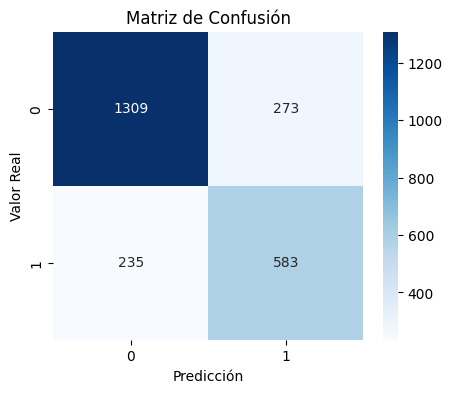

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

## Evaluación del modelo

Para validar el desempeño del modelo se utilizaron métricas básicas de clasificación:

1. Accuracy: proporción total de predicciones correctas
2. Precision: qué tan precisas son las predicciones positivas
3.  Recall: capacidad del modelo para detectar correctamente los casos positivos
4.  F1-score: equilibrio entre precision y recall

Además, se utilizó una *matriz de confusión* para visualizar los aciertos y errores del modelo, distinguiendo entre verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

Estas métricas permiten evaluar si el modelo resulta útil para clasificar correctamente casos de ansiedad alta.

## Conclusiones

A partir del dataset seleccionado, fue posible construir un modelo de clasificación para predecir niveles altos de ansiedad en usuarios de redes sociales.

La etapa de selección de variables permitió identificar cuáles eran los factores más relevantes para la predicción, reduciendo la dimensionalidad del conjunto de datos y simplificando el modelo.

El algoritmo Random Forest mostró un desempeño adecuado para esta tarea, logrando clasificar los casos con un nivel aceptable de precisión según las métricas obtenidas.

En términos sustantivos, los resultados sugieren que variables como la edad, el tiempo de uso de pantalla, el uso nocturno de redes sociales, la duración del sueño y los síntomas depresivos pueden contribuir a identificar perfiles con mayor probabilidad de ansiedad alta.

Como limitación, debe considerarse que se trata de un análisis observacional y que el modelo permite detectar asociaciones predictivas, pero no establecer relaciones causales.